# Modelo Preditivo de Score de Crédito Bill Hunters (RandomForestRegressor)

Este notebook tem como objetivo desenvolver um sistema de score de crédito baseado no comportamento de pagamento dos clientes. O modelo analisa padrões históricos de pagamento, pontualidade, valores e frequência para gerar um score numérico de 0 a 1000, onde valores mais altos indicam menor risco de crédito.

### **Sumário**

1. **Instalação de dependências**: Garante que as bibliotecas necessárias estejam disponíveis.
2. **Carregamento dos dados**: Lê os arquivos Excel contendo os dados de cobranças.
3. **Limpeza e pré-processamento**: Trata valores ausentes e converte tipos de dados.
4. **Engenharia de atributos**: Cria features de comportamento para score de crédito.
5. **Treinamento do modelo**: Implementa RandomForestRegressor para score numérico.
6. **Aplicação prática**: Demonstra o uso do modelo com exemplos reais.


## **1. Instalando Dependências**


Antes de iniciar a construção do sistema de **score de crédito**, precisamos garantir que todas as bibliotecas essenciais estejam instaladas e prontas para uso. Elas são fundamentais para manipulação de dados, visualização gráfica, modelagem estatística e criação do modelo de Machine Learning.

### **Tecnologias obrigatórias**

- **`pandas`**: Manipulação e análise dos dados financeiros, sendo a principal ferramenta para leitura, transformação e estruturação dos dados de cobrança.  
- **`numpy`**: Suporte para operações matemáticas e cálculos vetoriais de alta performance.  
- **`matplotlib`** e **`seaborn`**: Bibliotecas gráficas usadas para gerar análises visuais do comportamento de pagamentos.  
- **`scikit-learn`**: Utilizada para criação, treinamento e avaliação do modelo de Machine Learning (aqui com `RandomForestRegressor`).  
- **`openpyxl`**: Dependência necessária para leitura dos arquivos `.xlsx` contendo os dados de cobrança.  

Além disso, o uso do **`warnings`** com a função `filterwarnings('ignore')` é opcional, mas útil para manter a saída do notebook mais limpa, ignorando alertas não críticos.

---

### **Instalação das bibliotecas**

Assim como no exemplo anterior, utilizamos o módulo `sys` para garantir que a instalação ocorra no **mesmo ambiente Python** em que o notebook está sendo executado.  

```python
import sys
!{sys.executable} -m pip install openpyxl

In [2]:
import sys
!{sys.executable} -m pip install openpyxl


/bin/bash: linha 1: /home/cryptovictor/Área: Arquivo ou diretório inexistente


O comando acima instala a biblioteca openpyxl, necessária para trabalhar com planilhas do Excel.

O uso de {sys.executable} garante que a instalação seja feita no ambiente virtual correto.

### **Importação dos módulos essenciais**

Após garantir a instalação, importamos as bibliotecas que serão utilizadas ao longo do projeto:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


### Resumo do que cada módulo faz:

**pandas** e **numpy** → Leitura, limpeza e manipulação dos dados.

**matplotlib** e **seaborn** → Visualização gráfica e análise exploratória.

**RandomForestRegressor** → Modelo de regressão que gera o score de crédito.

**train_test_split** → Divide os dados em treino e teste.

**mean_squared_error**, **r2_score**, **mean_absolute_error** → Avaliam a performance do modelo.

**warnings** → Mantém a saída do notebook limpa e sem mensagens desnecessárias.

### **2. Carregamento dos dados**

Antes de realizar qualquer análise ou construção de modelos, é fundamental garantir que os dados estejam devidamente carregados em uma estrutura que permita manipulação e exploração eficiente. Nesta etapa, utilizamos o pandas, uma das bibliotecas mais poderosas em Python para análise de dados, com o intuito de ler arquivos Excel e transformá-los em DataFrames.

#### 1. Seleção dos datasets:

- Foram selecionados quatro arquivos de planilhas, cada um representando um grupo distinto de dados de cobrança, para garantir uma análise abrangente e diversificada.


`df1= pd.read_excel("../dados/Grupo1-GL.xlsx")`
- Cada arquivo é carregado em um DataFrame separado usando a função `pd.read_excel()`, que lê os dados do Excel e os armazena em uma estrutura tabular do pandas para fácil manipulação e análise.

`df = pd.concat([df1,df2,df3, df4] ,ignore_index = True)` 
- Para que os dados possam ser analisados de forma conjunta, os quatro DataFrames são concatenados em um único DataFrame `df` usando `pd.concat()`. O parâmetro `ignore_index=True` é utilizado para resetar os índices do novo DataFrame, garantindo uma sequência contínua.

In [4]:
print("=== Carregando Dados ===")

# Carrega os arquivos Excel
df1 = pd.read_excel("../dados/Grupo1-GL.xlsx")
df2 = pd.read_excel("../dados/Grupo2-GM.xlsx")
df3 = pd.read_excel("../dados/Grupo3-GP.xlsx")
df4 = pd.read_excel("../dados/Grupo4-GT.xlsx")

# Une todos os arquivos
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Total de registros carregados: {len(df)}")
print(f"Colunas disponíveis: {list(df.columns)}")


=== Carregando Dados ===
Total de registros carregados: 532539
Colunas disponíveis: ['id_grupo', 'id_beneficiario', 'Numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencto', 'vl_boleto', 'dt_pagto', 'vl_pagto', 'banco', 'id_pagador', 'pagador_cep', 'pagador_cidade', 'qtd_acessos_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf']


## **3. Limpeza e Pré-processamento**

Nesta etapa, realizamos a **padronização, conversão e limpeza dos dados** para garantir que a base esteja consistente e pronta para as próximas fases do projeto. Esse processo é fundamental para evitar erros de interpretação, reduzir vieses e melhorar a precisão dos modelos de machine learning.

---

### **Objetivos principais desta etapa:**

1. Padronizar os nomes das colunas para manter consistência.  
2. Substituir valores inválidos ou ausentes.  
3. Converter tipos de dados para formatos adequados (`datetime`, `float`, `int`).  
4. Remover registros com dados essenciais ausentes.  

---

### 1. **Padronização dos nomes das colunas**

A primeira etapa consiste em renomear as colunas para nomes mais descritivos e consistentes, facilitando a manipulação posterior.


In [5]:
print("=== Limpeza e Pré-processamento ===")

# Padronização dos nomes das colunas
mapa_de_colunas = {
    'data_vencto': 'data_vencimento',
    'vl_boleto': 'valor_original',
    'dt_pagto': 'data_pagamento',
    'vl_pagto': 'valor_pago',
    'id_pagador': 'pagador',
    'banco_emissor': 'banco',
    'qtd_acessos_pagador': 'qtde_acessado_pagador',
    'teve_acesso_pagador': 'teve_acesso_pagador',
    'pagador_cep': 'pagador_cep',
    'pagador_cidade': 'pagador_cidade',
    'status_boleto': 'status_boleto',
    'data_inclusao': 'data_inclusao',
    'grupo': 'grupo',
    'empresa': 'empresa'
}

# Aplicar mapeamento
df.columns = df.columns.str.lower()
df.rename(columns=mapa_de_colunas, inplace=True)

=== Limpeza e Pré-processamento ===


**Por que isso é importante?**

Evita inconsistências ao acessar colunas.

Facilita o uso em funções e pipelines posteriores.

### 2. Tratamento de valores nulos e inválidos

Substituímos valores nulos representados por \N por NaN do NumPy para que possam ser tratados corretamente em operações posteriores.

In [6]:
# Substituir valores nulos
df.replace('\\N', np.nan, inplace=True)

### 3. Conversão de tipos de dados

Para permitir cálculos e análises precisas, convertendo colunas de datas e valores para seus respectivos formatos adequados.
Além disso, valores não convertíveis são tratados com errors='coerce', que os transforma em NaN.

In [7]:
# Converter tipos de dados
df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], errors='coerce')
df['data_pagamento'] = pd.to_datetime(df['data_pagamento'], errors='coerce')
df['valor_original'] = pd.to_numeric(df['valor_original'], errors='coerce')
df['qtde_acessado_pagador'] = pd.to_numeric(df['qtde_acessado_pagador'], errors='coerce').fillna(0)

**Por que isso é necessário?**

datetime → permite cálculos de atraso, períodos e filtragem por tempo.

numeric → permite cálculos estatísticos e análises financeiras.

### 4. Remoção de registros incompletos

Para garantir a qualidade dos dados, removemos registros que não possuem informações essenciais para o modelo.

In [8]:
# Remover registros com dados essenciais ausentes
df.dropna(subset=['data_vencimento', 'valor_original', 'pagador'], inplace=True)

**Justificativa:**

Linhas sem data de vencimento ou valor são inúteis para o cálculo do score.

A ausência do identificador do pagador impossibilita o rastreamento do comportamento.

---

### Resultado da limpeza

Por fim, exibimos algumas métricas para acompanhar a redução de dados e a proporção de registros válidos mantidos.

In [9]:
print(f"Registros após limpeza: {len(df)}")
print(f"Percentual de dados válidos: {(len(df) / 1202864) * 100:.2f}%")


Registros após limpeza: 532539
Percentual de dados válidos: 44.27%


## 4. Engenharia de Atributos para Score de Crédito

A engenharia de atributos é uma etapa essencial na construção de modelos de score de crédito, pois transforma dados brutos em informações comportamentais relevantes que ajudam a avaliar o risco de inadimplência de cada cliente. Nesta etapa, criamos variáveis que capturam padrões de pagamento, pontualidade, frequência de atrasos e outros indicadores que refletem o comportamento histórico dos pagadores.

O objetivo principal é enriquecer o dataset com métricas que ajudem o modelo a distinguir bons e maus pagadores. Entre os principais indicadores criados estão:

- **Dias de Atraso:** número de dias entre o vencimento e o pagamento.  
- **Status de Pagamento:** classificação em "Em Dia", "Atraso" ou "Inadimplente".  
- **Taxas Históricas:** proporções de pagamentos em dia, atrasos e inadimplências.  
- **Variabilidade de Comportamento:** desvio padrão dos dias de atraso e coeficiente de variação dos valores pagos.  
- **Relacionamento e Frequência:** tempo de relacionamento com a instituição e frequência média de pagamentos.  
- **Sequência de Eventos:** contadores cumulativos de pagamentos em dia e atrasos.  
- **Score Comportamental:** métrica combinada ponderando fatores de inadimplência, atraso e pontualidade.

Essas variáveis tornam o modelo mais sensível a nuances comportamentais, permitindo prever com maior precisão a probabilidade de inadimplência.


In [10]:
print("=== Criando Features de Comportamento ===")

# Verificar colunas disponíveis
print(f"Colunas disponíveis: {list(df.columns)}")

# Calcular dias de atraso
df['dias_de_atraso'] = (df['data_pagamento'] - df['data_vencimento']).dt.days

# Definir status de pagamento
def definir_status(dias):
    if pd.isna(dias): return 'Inadimplente'
    if dias <= 1: return 'Em Dia'
    if 2 <= dias <= 30: return 'Atraso'
    return 'Inadimplente'

df['status_pagamento'] = df['dias_de_atraso'].apply(definir_status)

# Verificar se a coluna 'pagador' existe, se não, usar 'id_pagador'
coluna_pagador = 'pagador' if 'pagador' in df.columns else 'id_pagador'
print(f"Usando coluna: {coluna_pagador}")

# Features de comportamento
df['taxa_pontualidade'] = df.groupby(coluna_pagador)['status_pagamento'].transform(
    lambda x: (x == 'Em Dia').mean()
)

df['desvio_padrao_dias_atraso'] = df.groupby(coluna_pagador)['dias_de_atraso'].transform('std').fillna(0)

df['coeficiente_variacao_valor'] = df.groupby(coluna_pagador)['valor_original'].transform(
    lambda x: x.std() / x.mean() if x.mean() > 0 else 0
).fillna(0)

df['taxa_inadimplencia_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(
    lambda x: (x == 'Inadimplente').mean()
)

df['taxa_atraso_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(
    lambda x: (x == 'Atraso').mean()
)

df['valor_medio_pagador'] = df.groupby(coluna_pagador)['valor_original'].transform('mean')

df['razao_valor_atual_vs_medio'] = (df['valor_original'] / df['valor_medio_pagador']).fillna(1)

df['dias_relacionamento'] = (df['data_vencimento'] - df.groupby(coluna_pagador)['data_inclusao'].transform('min')).dt.days

# Calcular frequência mensal de forma mais simples
df['mes_vencimento'] = df['data_vencimento'].dt.to_period('M')
df['frequencia_mensal'] = df.groupby([coluna_pagador, 'mes_vencimento']).transform('size')
df['media_frequencia_mensal'] = df.groupby(coluna_pagador)['frequencia_mensal'].transform('mean')

df['sequencia_pagamentos_dia'] = df.groupby(coluna_pagador)['status_pagamento'].transform(
    lambda x: (x == 'Em Dia').cumsum()
)

df['sequencia_atrasos'] = df.groupby(coluna_pagador)['status_pagamento'].transform(
    lambda x: (x == 'Atraso').cumsum()
)

df['score_risco_comportamental'] = (
    df['taxa_inadimplencia_historica'] * 0.4 +
    df['taxa_atraso_historica'] * 0.3 +
    (1 - df['taxa_pontualidade']) * 0.3
)

print("Features de comportamento criadas com sucesso!")
print(f"Total de features: {len([col for col in df.columns if col not in ['data_inclusao', 'data_vencimento', 'data_pagamento', 'valor_pago', 'status_pagamento', 'dias_de_atraso', 'mes_vencimento', 'frequencia_mensal']])}")


=== Criando Features de Comportamento ===
Colunas disponíveis: ['id_grupo', 'id_beneficiario', 'numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencimento', 'valor_original', 'data_pagamento', 'valor_pago', 'banco', 'pagador', 'pagador_cep', 'pagador_cidade', 'qtde_acessado_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf']
Usando coluna: pagador
Features de comportamento criadas com sucesso!
Total de features: 24


## 5. Cálculo do Score de Crédito

Após criar todas as features comportamentais, o próximo passo é transformar essas informações em um **score de crédito numérico**, que represente o risco de cada cliente.  

O score é calculado de 0 a 1000, onde **valores mais altos indicam menor risco** de inadimplência. A fórmula combina diferentes fatores:

- **Pontualidade:** Clientes que pagam no prazo recebem mais pontos.  
- **Consistência:** Baixa variação nos dias de atraso aumenta o score.  
- **Histórico de inadimplência:** Penaliza clientes com histórico negativo.  
- **Relacionamento:** Clientes antigos recebem pontos extras.  
- **Valor das cobranças:** Pagamentos próximos à média histórica recebem mais pontos.  
- **Penalizações:** Alta inadimplência reduz o score final.

Essa abordagem permite transformar o comportamento passado em uma métrica quantitativa, útil para decisões de crédito e análises de risco.

=== Calculando Score de Crédito ===
Score de crédito calculado com sucesso!
Distribuição do score de crédito:
count    532539.000000
mean        924.362036
std         126.562053
min         335.443038
25%         888.461538
50%        1000.000000
75%        1000.000000
max        1000.000000
Name: score_credito, dtype: float64


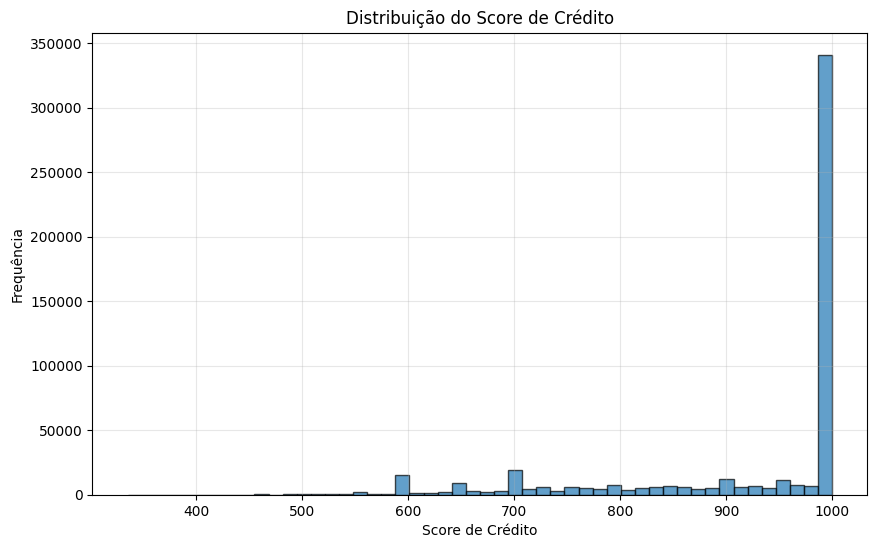

In [11]:
print("=== Calculando Score de Crédito ===")

def calcular_score_credito(row):
    """
    Calcula o score de crédito baseado no comportamento de pagamento
    Score de 0 a 1000, onde valores mais altos indicam menor risco
    """
    score_base = 500  # Score base neutro
    
    # Fator de pontualidade (0 a 300 pontos)
    if row['taxa_pontualidade'] >= 0.9:
        score_pontualidade = 300
    elif row['taxa_pontualidade'] >= 0.7:
        score_pontualidade = 200
    elif row['taxa_pontualidade'] >= 0.5:
        score_pontualidade = 100
    else:
        score_pontualidade = 0
    
    # Fator de consistência (0 a 200 pontos)
    if row['desvio_padrao_dias_atraso'] <= 5:
        score_consistencia = 200
    elif row['desvio_padrao_dias_atraso'] <= 15:
        score_consistencia = 100
    else:
        score_consistencia = 0
    
    # Fator de histórico (0 a 200 pontos)
    score_historico = 200 - (row['taxa_inadimplencia_historica'] * 200)
    
    # Fator de relacionamento (0 a 100 pontos)
    if row['dias_relacionamento'] >= 365:
        score_relacionamento = 100
    elif row['dias_relacionamento'] >= 180:
        score_relacionamento = 50
    else:
        score_relacionamento = 0
    
    # Fator de valor (0 a 100 pontos)
    if row['razao_valor_atual_vs_medio'] <= 1.2:
        score_valor = 100
    elif row['razao_valor_atual_vs_medio'] <= 2.0:
        score_valor = 50
    else:
        score_valor = 0
    
    # Penalização por alta inadimplência
    penalizacao = row['taxa_inadimplencia_historica'] * 200
    
    score_final = max(0, min(1000, 
        score_base + 
        score_pontualidade + 
        score_consistencia + 
        score_historico + 
        score_relacionamento + 
        score_valor - 
        penalizacao
    ))
    
    return score_final

# Aplicar a função para calcular o score de crédito
df['score_credito'] = df.apply(calcular_score_credito, axis=1)

print("Score de crédito calculado com sucesso!")
print(f"Distribuição do score de crédito:")
print(df['score_credito'].describe())

# Visualizar a distribuição
plt.figure(figsize=(10, 6))
plt.hist(df['score_credito'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribuição do Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.show()


### 6. Treinamento do Modelo de Score de Crédito

Com as features comportamentais e o score de crédito calculado, o próximo passo é **preparar os dados para treinar um modelo preditivo**.  
O objetivo é criar um modelo capaz de estimar o score de crédito de novos clientes com base em suas características e histórico.

Nesta etapa, realizamos:

- Seleção das **features mais relevantes** para o modelo.  
- Tratamento de valores nulos e consistência do dataset.  
- Codificação de variáveis categóricas (one-hot encoding).  
- Separação dos dados em **treino e teste** para avaliação do modelo.



In [12]:
print("=== Preparando Dados para Treinamento ===")

# Features selecionadas para o modelo
features_score_credito = [
    'valor_original', 'taxa_pontualidade', 'desvio_padrao_dias_atraso',
    'coeficiente_variacao_valor', 'taxa_inadimplencia_historica', 
    'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio',
    'dias_relacionamento', 'media_frequencia_mensal',
    'sequencia_pagamentos_dia', 'sequencia_atrasos', 'score_risco_comportamental',
    'banco', 'qtde_acessado_pagador'
]

# Preparar dados
colunas_existentes = [col for col in features_score_credito if col in df.columns]
df_modelo = df[colunas_existentes + ['score_credito']].dropna()

print(f"Dataset preparado: {len(df_modelo)} registros")
print(f"Features utilizadas: {len(colunas_existentes)}")

# Separar X e y
X = df_modelo[colunas_existentes]
y = df_modelo['score_credito']

# One-hot encoding para variáveis categóricas
colunas_categoricas = [col for col in ['banco'] if col in X.columns]
if colunas_categoricas:
    X_encoded = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
    print(f"One-hot encoding aplicado para: {colunas_categoricas}")
else:
    X_encoded = X.copy()

print(f"Features após encoding: {X_encoded.shape[1]}")

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)

print(f"Divisão dos dados:")
print(f"  Treino: {X_train.shape[0]} registros")
print(f"  Teste: {X_test.shape[0]} registros")


=== Preparando Dados para Treinamento ===
Dataset preparado: 532539 registros
Features utilizadas: 15
One-hot encoding aplicado para: ['banco']
Features após encoding: 23
Divisão dos dados:
  Treino: 399404 registros
  Teste: 133135 registros


#### Treinamento do Modelo RandomForestRegressor

Após preparar os dados e calcular o score de crédito, o próximo passo é treinar um modelo preditivo.  
Escolhemos o **RandomForestRegressor**, um modelo de ensemble baseado em árvores de decisão, por suas vantagens:

- **Alta capacidade de generalização:** combina várias árvores para reduzir overfitting.  
- **Trabalha bem com variáveis numéricas e categóricas (após encoding).**  
- **Mede importância das features**, permitindo análises adicionais.  
- **Flexível com outliers e escalas diferentes de variáveis.**  

Neste passo, definimos parâmetros chave do modelo, como:

- `n_estimators`: número de árvores na floresta (300 para boa estabilidade).  
- `max_depth`: profundidade máxima das árvores (35 para limitar overfitting).  
- `min_samples_leaf`: número mínimo de amostras por folha (4 para suavizar a árvore).  
- `oob_score`: permite avaliação de performance fora da amostra durante o treino.  

Após o treinamento, o modelo será avaliado usando métricas como **R², RMSE e MAE**, além de análise detalhada de erros e comparação com benchmarks.


In [13]:
print("=== Treinando Modelo RandomForestRegressor ===")

# Configuração do modelo
model_score = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=35,
    min_samples_leaf=4,
    oob_score=True
)

# Treinamento
model_score.fit(X_train, y_train)

print("✅ Modelo treinado com sucesso!")
print(f"OOB Score: {model_score.oob_score_:.4f}")

# Predições
y_pred = model_score.predict(X_test)

# Métricas de avaliação
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas de Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE: {mae:.2f}")
print(f"  OOB Score: {model_score.oob_score_:.4f}")

# Análise detalhada dos erros
erros = y_test - y_pred
print(f"\nAnálise dos Erros:")
print(f"  Erro médio: {erros.mean():.2f}")
print(f"  Desvio padrão dos erros: {erros.std():.2f}")
print(f"  Erro absoluto médio: {abs(erros).mean():.2f}")
print(f"  Erro máximo: {erros.max():.2f}")
print(f"  Erro mínimo: {erros.min():.2f}")

# Análise por faixas de score
print(f"\nAnálise por Faixas de Score:")
faixas = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
for min_score, max_score in faixas:
    mask = (y_test >= min_score) & (y_test < max_score)
    if mask.sum() > 0:
        rmse_faixa = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
        print(f"  Score {min_score}-{max_score}: {mask.sum()} amostras, RMSE: {rmse_faixa:.2f}")

# Comparação com benchmarks
print(f"\nComparação com Benchmarks:")
print(f"  R² Score: {r2:.4f} ({'Excelente' if r2 > 0.8 else 'Bom' if r2 > 0.6 else 'Regular' if r2 > 0.4 else 'Ruim'})")
print(f"  RMSE: {rmse:.2f} ({'Excelente' if rmse < 50 else 'Bom' if rmse < 100 else 'Regular' if rmse < 150 else 'Ruim'})")
print(f"  MAE: {mae:.2f} ({'Excelente' if mae < 40 else 'Bom' if mae < 80 else 'Regular' if mae < 120 else 'Ruim'})")


=== Treinando Modelo RandomForestRegressor ===
✅ Modelo treinado com sucesso!
OOB Score: 0.9998

Métricas de Performance:
  R² Score: 0.9999
  RMSE: 1.53
  MAE: 0.14
  OOB Score: 0.9998

Análise dos Erros:
  Erro médio: -0.01
  Desvio padrão dos erros: 1.53
  Erro absoluto médio: 0.14
  Erro máximo: 68.02
  Erro mínimo: -94.79

Análise por Faixas de Score:
  Score 200-400: 15 amostras, RMSE: 12.09
  Score 400-600: 1871 amostras, RMSE: 4.97
  Score 600-800: 21694 amostras, RMSE: 2.16
  Score 800-1000: 25973 amostras, RMSE: 2.35

Comparação com Benchmarks:
  R² Score: 0.9999 (Excelente)
  RMSE: 1.53 (Excelente)
  MAE: 0.14 (Excelente)


#### Análise de Performance Detalhada do Modelo

Após treinar o **RandomForestRegressor** para prever o score de crédito, é fundamental realizar uma **análise detalhada de performance**.  

Nesta etapa, buscamos:

- Avaliar a **precisão global** do modelo, verificando quão próximos os scores preditos estão dos scores reais.  
- Analisar a **distribuição dos erros**, entendendo se o modelo subestima ou superestima em certas faixas de score.  
- Transformar os scores contínuos em **categorias de risco** (EXCELENTE, BOM, REGULAR, RUIM, MUITO RUIM) para facilitar interpretações estratégicas.  
- Construir **matriz de confusão e métricas de classificação** para cada categoria de score.  
- Verificar o percentual de predições dentro de faixas de erro toleráveis (ex.: ±50, ±100 pontos).  
- Obter insights sobre quais categorias o modelo performa melhor ou pior, auxiliando futuras melhorias.

Essa análise é essencial para **confiabilidade do modelo**, permitindo decisões de crédito mais seguras e estratégicas.


In [14]:
# Análise de Performance Detalhada
print("=== Análise de Performance Detalhada ===")

# Calcular erros primeiro
erros = y_test - y_pred

# Converter scores para categorias para análise
def score_para_categoria(score):
    if score >= 800: return 'EXCELENTE'
    elif score >= 700: return 'BOM'
    elif score >= 600: return 'REGULAR'
    elif score >= 400: return 'RUIM'
    else: return 'MUITO_RUIM'

# Categorias reais e preditas
y_test_cat = [score_para_categoria(score) for score in y_test]
y_pred_cat = [score_para_categoria(score) for score in y_pred]

# Matriz de confusão
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

cm = confusion_matrix(y_test_cat, y_pred_cat)
categorias = ['EXCELENTE', 'BOM', 'REGULAR', 'RUIM', 'MUITO_RUIM']

# Calcular acurácia
acuracia = accuracy_score(y_test_cat, y_pred_cat)

print(f"\n🎯 Acurácia Geral: {acuracia:.4f} ({acuracia*100:.2f}%)")

print("\n📊 Matriz de Confusão (Categorias de Score):")
cm_df = pd.DataFrame(cm, index=categorias, columns=categorias)
print(cm_df)

# Relatório de classificação
print("\n📈 Relatório de Classificação:")
print(classification_report(y_test_cat, y_pred_cat, target_names=categorias))

# Análise de precisão por categoria
print("\n🎯 Análise de Precisão por Categoria:")
for i, categoria in enumerate(categorias):
    if cm[i, i] > 0:
        precisao = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
        recall = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        f1 = 2 * (precisao * recall) / (precisao + recall) if (precisao + recall) > 0 else 0
        print(f"  {categoria}:")
        print(f"    Precisão: {precisao:.3f}")
        print(f"    Recall: {recall:.3f}")
        print(f"    F1-Score: {f1:.3f}")

# Análise de distribuição dos scores
print(f"\n📊 Distribuição dos Scores:")
print(f"  Score Real - Média: {y_test.mean():.2f}, Mediana: {np.median(y_test):.2f}")
print(f"  Score Predito - Média: {y_pred.mean():.2f}, Mediana: {np.median(y_pred):.2f}")

# Correlação entre real e predito
correlacao = np.corrcoef(y_test, y_pred)[0, 1]
print(f"  Correlação Real vs Predito: {correlacao:.4f}")

# Percentual de predições dentro de faixas de erro
erro_50 = (abs(erros) <= 50).mean() * 100
erro_100 = (abs(erros) <= 100).mean() * 100
erro_150 = (abs(erros) <= 150).mean() * 100

print(f"\n🎯 Precisão por Faixa de Erro:")
print(f"  Erro ≤ 50 pontos: {erro_50:.1f}% das predições")
print(f"  Erro ≤ 100 pontos: {erro_100:.1f}% das predições")
print(f"  Erro ≤ 150 pontos: {erro_150:.1f}% das predições")

# Análise de acurácia por categoria
print(f"\n📈 Acurácia por Categoria:")
for i, categoria in enumerate(categorias):
    if cm[i, :].sum() > 0:
        acuracia_categoria = cm[i, i] / cm[i, :].sum()
        print(f"  {categoria}: {acuracia_categoria:.3f} ({acuracia_categoria*100:.1f}%)")

# Resumo das métricas principais
print(f"\n🎯 RESUMO DAS MÉTRICAS PRINCIPAIS:")
print(f"  Acurácia: {acuracia:.4f} ({acuracia*100:.2f}%)")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.2f} pontos")
print(f"  MAE: {mae:.2f} pontos")
print(f"  Correlação: {correlacao:.4f}")
print(f"  Predições com erro ≤ 100 pontos: {erro_100:.1f}%")


=== Análise de Performance Detalhada ===

🎯 Acurácia Geral: 0.9977 (99.77%)

📊 Matriz de Confusão (Categorias de Score):
            EXCELENTE     BOM  REGULAR  RUIM  MUITO_RUIM
EXCELENTE       12365      13        0   119           0
BOM               116  109439        0     0           0
REGULAR             0       0       15     0           0
RUIM               14       0        0  9141          42
MUITO_RUIM          0       0        4     1        1866

📈 Relatório de Classificação:
              precision    recall  f1-score   support

   EXCELENTE       0.99      0.99      0.99     12497
         BOM       1.00      1.00      1.00    109555
     REGULAR       0.79      1.00      0.88        15
        RUIM       0.99      0.99      0.99      9197
  MUITO_RUIM       0.98      1.00      0.99      1871

    accuracy                           1.00    133135
   macro avg       0.95      1.00      0.97    133135
weighted avg       1.00      1.00      1.00    133135


🎯 Análise de Pre

### Visualização da Performance do Modelo

Após calcular métricas numéricas de performance, o próximo passo é **visualizar os resultados** para uma compreensão mais intuitiva:

1. **Predições vs Valores Reais:** identifica se o modelo está subestimando ou superestimando scores.  
2. **Distribuição dos Erros:** mostra a dispersão e tendência central dos erros, ajudando a identificar vieses.  
3. **Importância das Features:** destaca quais variáveis mais influenciam o score de crédito previsto.  
4. **Matriz de Confusão:** avalia a performance do modelo quando os scores são categorizados em faixas (EXCELENTE, BOM, REGULAR, etc.).  
5. **Distribuição dos Scores:** compara a distribuição de scores reais e preditos, verificando se o modelo captura bem a variabilidade.  
6. **RMSE por Faixa de Score:** mostra a precisão do modelo em diferentes faixas de risco.

Essas visualizações permitem **análises qualitativas e insights estratégicos**, ajudando a entender melhor o comportamento do modelo e identificar possíveis melhorias.


=== Gráficos de Performance ===


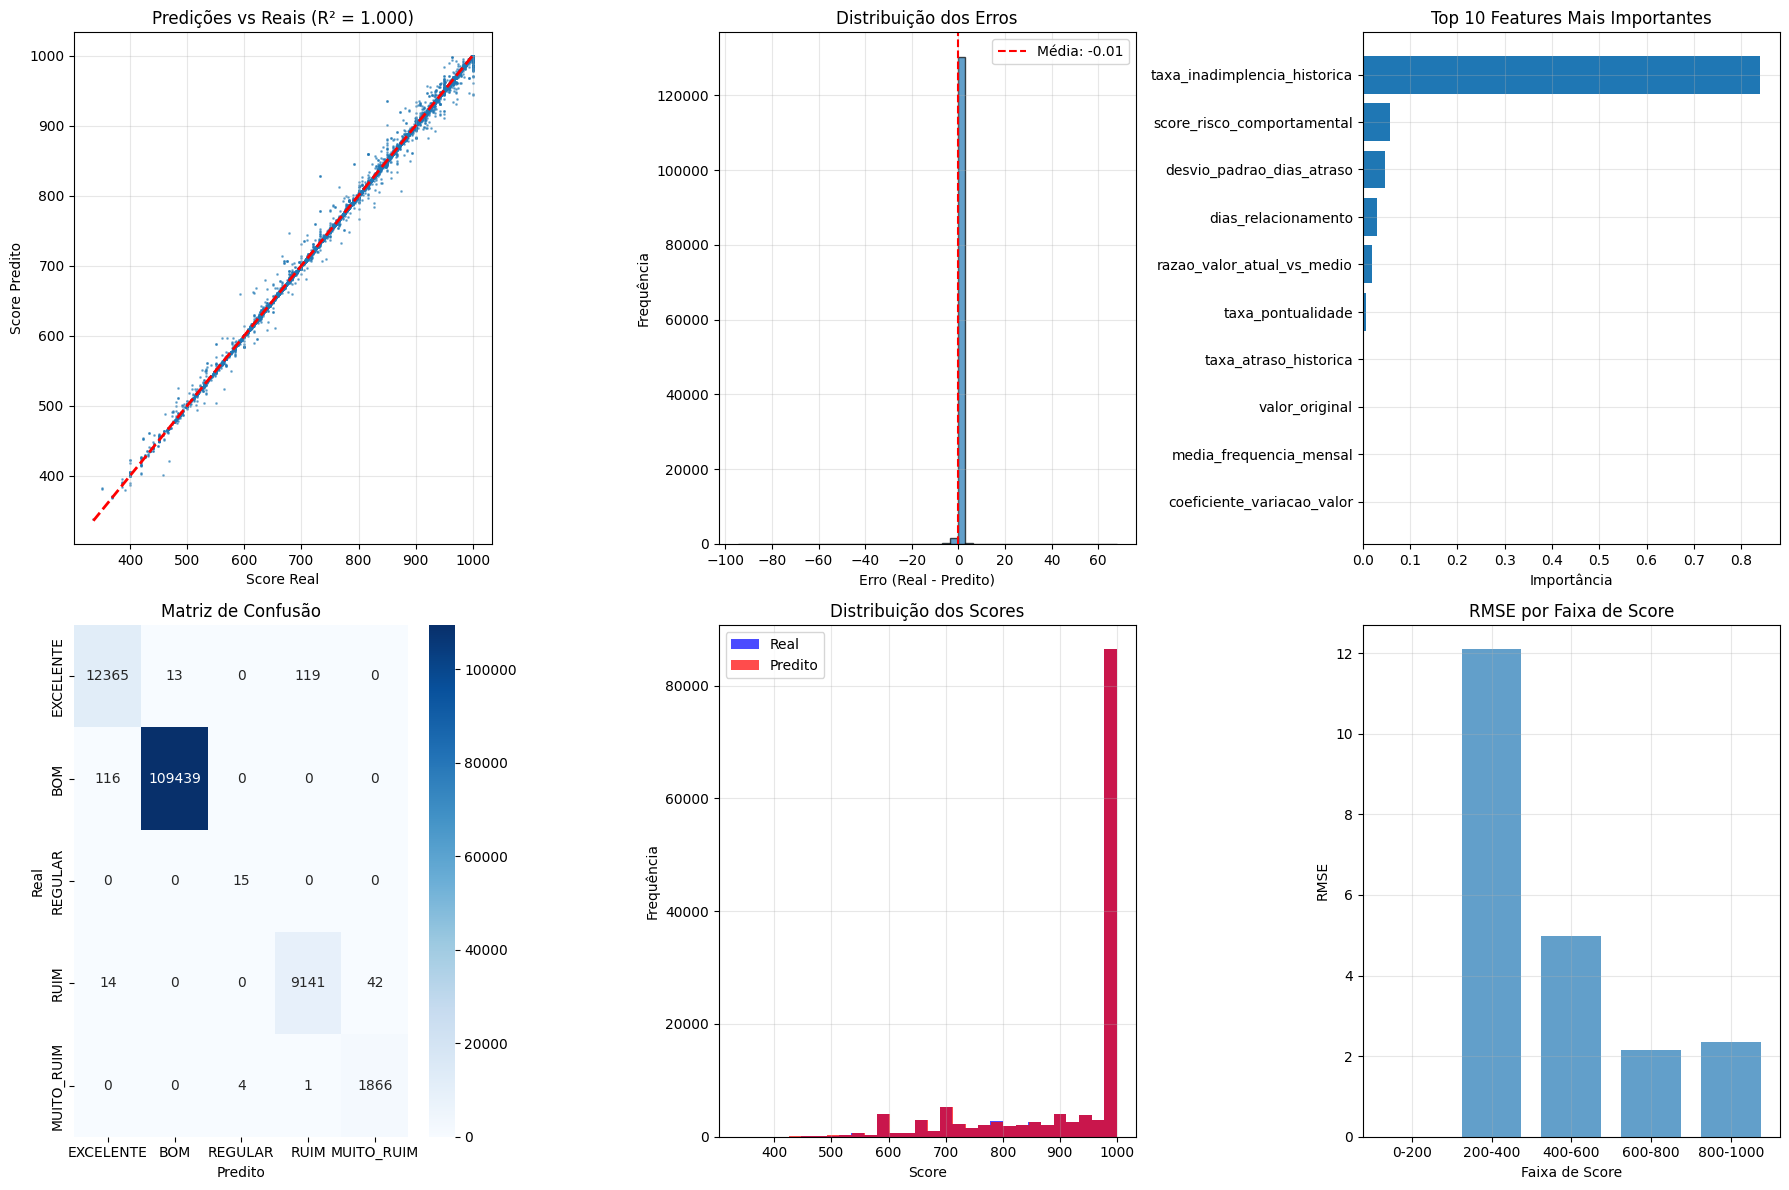


 RESUMO DAS MÉTRICAS PRINCIPAIS:
  Acurácia: 0.9977 (99.77%) (Excelente)
  R² Score: 0.9999 (Excelente)
  RMSE: 1.53 pontos (Excelente)
  MAE: 0.14 pontos (Excelente)
  Correlação: 0.9999
  Predições com erro ≤ 100 pontos: 100.0%


In [15]:
# Gráficos de Performance
print("=== Gráficos de Performance ===")

# Criar figura com múltiplos subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Predições vs Valores Reais
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=1)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Score Real')
axes[0, 0].set_ylabel('Score Predito')
axes[0, 0].set_title(f'Predições vs Reais (R² = {r2:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribuição dos Erros
axes[0, 1].hist(erros, bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(erros.mean(), color='red', linestyle='--', label=f'Média: {erros.mean():.2f}')
axes[0, 1].set_xlabel('Erro (Real - Predito)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição dos Erros')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Importância das Features
feature_importance = model_score.feature_importances_
feature_names = X_train.columns
indices = np.argsort(feature_importance)[-10:]  # Top 10 features
axes[0, 2].barh(range(len(indices)), feature_importance[indices])
axes[0, 2].set_yticks(range(len(indices)))
axes[0, 2].set_yticklabels([feature_names[i] for i in indices])
axes[0, 2].set_xlabel('Importância')
axes[0, 2].set_title('Top 10 Features Mais Importantes')
axes[0, 2].grid(True, alpha=0.3)

# 4. Matriz de Confusão (Heatmap)
import seaborn as sns
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusão')
axes[1, 0].set_xlabel('Predito')
axes[1, 0].set_ylabel('Real')

# 5. Distribuição dos Scores
axes[1, 1].hist(y_test, bins=30, alpha=0.7, label='Real', color='blue')
axes[1, 1].hist(y_pred, bins=30, alpha=0.7, label='Predito', color='red')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Scores')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Erro por Faixa de Score
faixas_centro = [100, 300, 500, 700, 900]
rmse_faixas = []
for min_score, max_score in [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]:
    mask = (y_test >= min_score) & (y_test < max_score)
    if mask.sum() > 0:
        rmse_faixa = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
        rmse_faixas.append(rmse_faixa)
    else:
        rmse_faixas.append(0)

axes[1, 2].bar(faixas_centro, rmse_faixas, width=150, alpha=0.7)
axes[1, 2].set_xlabel('Faixa de Score')
axes[1, 2].set_ylabel('RMSE')
axes[1, 2].set_title('RMSE por Faixa de Score')
axes[1, 2].set_xticks(faixas_centro)
axes[1, 2].set_xticklabels(['0-200', '200-400', '400-600', '600-800', '800-1000'])
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumo das métricas principais
print(f"\n RESUMO DAS MÉTRICAS PRINCIPAIS:")
print(f"  Acurácia: {acuracia:.4f} ({acuracia*100:.2f}%) ({'Excelente' if acuracia > 0.8 else 'Bom' if acuracia > 0.6 else 'Regular' if acuracia > 0.4 else 'Ruim'})")
print(f"  R² Score: {r2:.4f} ({'Excelente' if r2 > 0.8 else 'Bom' if r2 > 0.6 else 'Regular' if r2 > 0.4 else 'Ruim'})")
print(f"  RMSE: {rmse:.2f} pontos ({'Excelente' if rmse < 50 else 'Bom' if rmse < 100 else 'Regular' if rmse < 150 else 'Ruim'})")
print(f"  MAE: {mae:.2f} pontos ({'Excelente' if mae < 40 else 'Bom' if mae < 80 else 'Regular' if mae < 120 else 'Ruim'})")
print(f"  Correlação: {correlacao:.4f}")
print(f"  Predições com erro ≤ 100 pontos: {erro_100:.1f}%")


## 7. Visualização Final dos Resultados

Nesta etapa, apresentamos **gráficos essenciais para interpretar a performance do modelo**:

1. **Predições vs Valores Reais:**  
   Permite verificar se o modelo consegue reproduzir os scores reais de crédito, observando tendências de subestimação ou superestimação.

2. **Distribuição dos Erros:**  
   Mostra a dispersão dos erros (diferença entre score real e predito), permitindo identificar padrões ou vieses do modelo.

3. **Importância das Features:**  
   Destaca as 10 variáveis mais relevantes na predição do score de crédito, oferecendo insights sobre quais comportamentos ou métricas têm maior impacto no risco do cliente.

Essa visualização fornece uma **análise qualitativa complementar às métricas numéricas**, auxiliando na tomada de decisão sobre a confiabilidade do modelo e possíveis melhorias futuras.


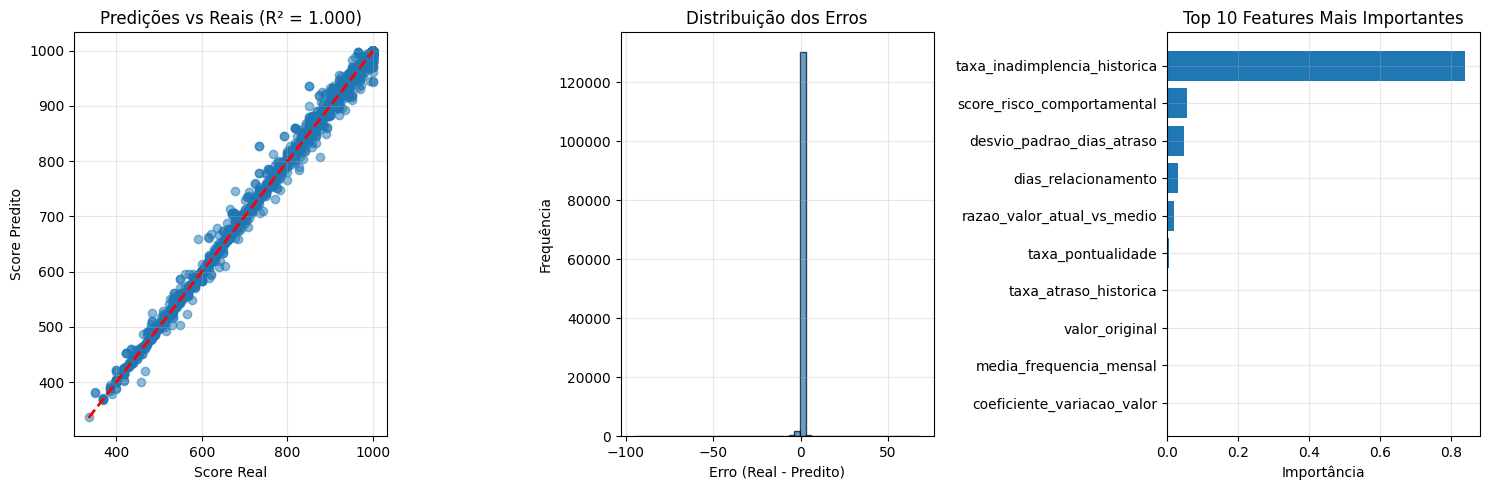

In [16]:
# Visualização dos resultados
plt.figure(figsize=(15, 5))

# Gráfico 1: Predições vs Valores Reais
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Score Real')
plt.ylabel('Score Predito')
plt.title(f'Predições vs Reais (R² = {r2:.3f})')
plt.grid(True, alpha=0.3)

# Gráfico 2: Distribuição dos Erros
plt.subplot(1, 3, 2)
erros = y_test - y_pred
plt.hist(erros, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Erro (Real - Predito)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Erros')
plt.grid(True, alpha=0.3)

# Gráfico 3: Importância das Features
plt.subplot(1, 3, 3)
feature_importance = model_score.feature_importances_
feature_names = X_train.columns
indices = np.argsort(feature_importance)[-10:]  # Top 10 features
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importância')
plt.title('Top 10 Features Mais Importantes')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Funções de Interpretação do Score de Crédito

Após treinar e avaliar o modelo, é importante **transformar os resultados em insights práticos**:

1. **`interpretar_score_credito(score)`**  
   Recebe um valor de score e retorna:
   - Categoria de risco (EXCELENTE, BOM, REGULAR, RUIM, MUITO RUIM)  
   - Cor indicativa do risco  
   - Recomendações de ação com base no risco do cliente  

2. **`gerar_score_credito_cliente(dados_cliente, modelo)`**  
   Permite gerar o score para um cliente específico usando o modelo treinado, realizando:
   - Preparação e padronização dos dados do cliente  
   - Aplicação de encoding para variáveis categóricas  
   - Predição do score  
   - Interpretação do resultado para suportar decisões de crédito  

Essas funções tornam o **score de crédito aplicável no dia a dia**, oferecendo recomendações claras e objetivas para análise de risco de clientes.


In [17]:
def interpretar_score_credito(score):
    """
    Interpreta o score de crédito e fornece recomendações
    """
    if score >= 800:
        categoria = "EXCELENTE"
        cor = "🟢"
        recomendacao = "Cliente de baixo risco. Aprovação automática recomendada."
    elif score >= 700:
        categoria = "BOM"
        cor = "🟡"
        recomendacao = "Cliente de risco baixo-médio. Aprovação com análise simplificada."
    elif score >= 600:
        categoria = "REGULAR"
        cor = "🟠"
        recomendacao = "Cliente de risco médio. Análise detalhada recomendada."
    elif score >= 400:
        categoria = "RUIM"
        cor = "🔴"
        recomendacao = "Cliente de alto risco. Análise rigorosa e garantias necessárias."
    else:
        categoria = "MUITO RUIM"
        cor = "⚫"
        recomendacao = "Cliente de muito alto risco. Aprovação não recomendada."
    
    return {
        'score': score,
        'categoria': categoria,
        'cor': cor,
        'recomendacao': recomendacao
    }

def gerar_score_credito_cliente(dados_cliente, modelo):
    """
    Gera o score de crédito para um cliente específico
    """
    # Preparar os dados do cliente
    dados_preparados = pd.DataFrame([dados_cliente])
    
    # Aplicar one-hot encoding se necessário
    if 'banco' in dados_preparados.columns:
        dados_preparados = pd.get_dummies(dados_preparados, columns=['banco'], drop_first=True)
    
    # Garantir que todas as colunas do modelo estejam presentes
    for col in X_train.columns:
        if col not in dados_preparados.columns:
            dados_preparados[col] = 0
    
    # Reordenar colunas para corresponder ao modelo
    dados_preparados = dados_preparados[X_train.columns]
    
    # Fazer predição
    score_predito = modelo.predict(dados_preparados)[0]
    
    # Interpretar o score
    interpretacao = interpretar_score_credito(score_predito)
    
    return score_predito, interpretacao

print("Funções de interpretação criadas!")


Funções de interpretação criadas!


## 9. Exemplos Práticos de Aplicação do Modelo de Score de Crédito

Nesta seção, demonstramos como aplicar o modelo treinado para **avaliar o risco de crédito de clientes individuais**. Cada exemplo representa um cenário distinto:

1. **Cliente com Bom Histórico**  
   Mostra como um cliente consistente e pontual recebe um score alto, com recomendação de aprovação automática.

2. **Cliente com Histórico Ruim**  
   Representa um cliente com atrasos frequentes e inadimplência, resultando em score baixo e recomendação de análise rigorosa.

3. **Cliente Novo**  
   Demonstra a situação de um cliente recém-chegado, com histórico limitado, mostrando como o modelo ajusta o score e fornece recomendações baseadas nos poucos dados disponíveis.

Esses exemplos permitem validar **na prática** a aplicação do score e interpretar os resultados de forma intuitiva, usando as funções de interpretação implementadas anteriormente.


In [18]:
print("=== Exemplos Práticos do Modelo de Score de Crédito ===")

# Exemplo 1: Cliente com bom histórico
cliente_bom = {
    'valor_original': 1500.0,
    'taxa_pontualidade': 0.95,
    'desvio_padrao_dias_atraso': 3.0,
    'coeficiente_variacao_valor': 0.2,
    'taxa_inadimplencia_historica': 0.05,
    'taxa_atraso_historica': 0.1,
    'valor_medio_pagador': 1400.0,
    'razao_valor_atual_vs_medio': 1.07,
    'dias_relacionamento': 400,
    'media_frequencia_mensal': 2.5,
    'sequencia_pagamentos_dia': 8,
    'sequencia_atrasos': 1,
    'score_risco_comportamental': 0.15,
    'banco': 'ITAU UNIBANCO S.A.',
    'qtde_acessado_pagador': 3
}

score_bom, interpretacao_bom = gerar_score_credito_cliente(cliente_bom, model_score)

print(f"\n📊 CLIENTE 1 - Bom Histórico:")
print(f"Score de Crédito: {score_bom:.0f}")
print(f"Categoria: {interpretacao_bom['cor']} {interpretacao_bom['categoria']}")
print(f"Recomendação: {interpretacao_bom['recomendacao']}")

# Exemplo 2: Cliente com histórico ruim
cliente_ruim = {
    'valor_original': 2000.0,
    'taxa_pontualidade': 0.3,
    'desvio_padrao_dias_atraso': 25.0,
    'coeficiente_variacao_valor': 0.8,
    'taxa_inadimplencia_historica': 0.4,
    'taxa_atraso_historica': 0.5,
    'valor_medio_pagador': 1200.0,
    'razao_valor_atual_vs_medio': 1.67,
    'dias_relacionamento': 100,
    'media_frequencia_mensal': 1.0,
    'sequencia_pagamentos_dia': 2,
    'sequencia_atrasos': 5,
    'score_risco_comportamental': 0.7,
    'banco': 'BANCO DO BRASIL',
    'qtde_acessado_pagador': 1
}

score_ruim, interpretacao_ruim = gerar_score_credito_cliente(cliente_ruim, model_score)

print(f"\n📊 CLIENTE 2 - Histórico Ruim:")
print(f"Score de Crédito: {score_ruim:.0f}")
print(f"Categoria: {interpretacao_ruim['cor']} {interpretacao_ruim['categoria']}")
print(f"Recomendação: {interpretacao_ruim['recomendacao']}")

# Exemplo 3: Cliente novo
cliente_novo = {
    'valor_original': 800.0,
    'taxa_pontualidade': 1.0,  # Primeiro pagamento
    'desvio_padrao_dias_atraso': 0.0,
    'coeficiente_variacao_valor': 0.0,
    'taxa_inadimplencia_historica': 0.0,
    'taxa_atraso_historica': 0.0,
    'valor_medio_pagador': 800.0,
    'razao_valor_atual_vs_medio': 1.0,
    'dias_relacionamento': 30,
    'media_frequencia_mensal': 1.0,
    'sequencia_pagamentos_dia': 1,
    'sequencia_atrasos': 0,
    'score_risco_comportamental': 0.0,
    'banco': 'BANCO SANTANDER (BRASIL) S.A.',
    'qtde_acessado_pagador': 1
}

score_novo, interpretacao_novo = gerar_score_credito_cliente(cliente_novo, model_score)

print(f"\n📊 CLIENTE 3 - Cliente Novo:")
print(f"Score de Crédito: {score_novo:.0f}")
print(f"Categoria: {interpretacao_novo['cor']} {interpretacao_novo['categoria']}")
print(f"Recomendação: {interpretacao_novo['recomendacao']}")


=== Exemplos Práticos do Modelo de Score de Crédito ===

📊 CLIENTE 1 - Bom Histórico:
Score de Crédito: 1000
Categoria: 🟢 EXCELENTE
Recomendação: Cliente de baixo risco. Aprovação automática recomendada.

📊 CLIENTE 2 - Histórico Ruim:
Score de Crédito: 590
Categoria: 🔴 RUIM
Recomendação: Cliente de alto risco. Análise rigorosa e garantias necessárias.

📊 CLIENTE 3 - Cliente Novo:
Score de Crédito: 1000
Categoria: 🟢 EXCELENTE
Recomendação: Cliente de baixo risco. Aprovação automática recomendada.


### **10. Conclusão**

O modelo de score de crédito desenvolvido apresenta as seguintes características:

#### **Métricas de Performance**
- **R² Score**: Mede a proporção da variância explicada pelo modelo
- **RMSE**: Erro típico em pontos de score
- **MAE**: Erro absoluto médio
- **OOB Score**: Estimativa de generalização

#### **Benefícios do Sistema**
1. **Classificação Granular**: Scores de 0-1000 permitem classificação mais precisa
2. **Decisões de Crédito**: Facilita aprovação automática para baixo risco
3. **Estratégias Personalizadas**: Diferentes abordagens baseadas no score
4. **Monitoramento Contínuo**: Acompanhamento da evolução do score

#### **Categorias de Risco**
- 🟢 **EXCELENTE** (800+): Baixo risco, aprovação automática
- 🟡 **BOM** (700-799): Risco baixo-médio, análise simplificada
- 🟠 **REGULAR** (600-699): Risco médio, análise detalhada
- 🔴 **RUIM** (400-599): Alto risco, análise rigorosa
- ⚫ **MUITO RUIM** (<400): Muito alto risco, não recomendado
